# Plotting

One of the main usecases of `SegTraQ` is to compare different segmentation methods. To facilitate this task, you can make use of the plotting module (`pl`).
In order to use it, you need to prepare your data in the form of a dictionary that maps the method name to the corresponding `SegTraQ` object.

## Data Preparation

First, we need to get the data into the right format. This closely follows the [Xenium Focus](10x_xenium_focus.ipynb).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import anndata as ad
import scanpy as sc
import spatialdata as sd

import segtraq

warnings.filterwarnings(action="ignore")

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: Fut

In [2]:
# === READING SPATIALDATA OBJECTS ===
sdata_xenium_ws = sd.read_zarr("../../data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/proseg2.zarr")
sdata_segger_ws = sd.read_zarr("../../data/segger.zarr")


# === REMOVING CONTROL PROBES ===
def subset_points(sdata, min_qv=20):
    pts = sdata.points["transcripts"]

    prefixes = (
        "NegControlProbe_",
        "antisense_",
        "NegControlCodeword",
        "BLANK_",
        "Blank-",
        "NegPrb",
        "DeprecatedCodeword_",
        "Intergenic_Region_",
        "UnassignedCodeword_",
        "Human_",
    )

    mask = pts["feature_name"].str.startswith(prefixes) | (pts["qv"] < min_qv)
    pts_sub = pts[~mask]

    sdata.points["transcripts"] = pts_sub


subset_points(sdata_xenium_ws)
subset_points(sdata_bidcell_ws)
subset_points(sdata_proseg_ws)
subset_points(sdata_segger_ws, min_qv=30)

# === CROPPING ===
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h


def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)
sdata_segger = crop(sdata_segger_ws)

# === CREATING SEGTRAQ OBJECTS ===
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_background_id=0,
    tables_area_volume_key="volume",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_segger = segtraq.SegTraQ(
    sdata_segger, images_key="image", tables_centroid_x_key="cell_centroid_x", tables_centroid_y_key="cell_centroid_y"
)

# === PUTTING EVERYTHING INTO A DICTIONARY ===
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg, "segger": st_segger}

no parent found for <ome_zarr.reader.Label object at 0x7efecc613e00>: None
no parent found for <ome_zarr.reader.Label object at 0x7efeca2765d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7efecc37e0d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7efeca2d76f0>: None
no parent found for <ome_zarr.reader.Label object at 0x7efeca25c640>: None
no parent found for <ome_zarr.reader.Label object at 0x7efec9573ad0>: None
no parent found for <ome_zarr.reader.Label object at 0x7efeca264380>: None
no parent found for <ome_zarr.reader.Label object at 0x7efeca264270>: None
no parent found for <ome_zarr.reader.Label object at 0x7efeca268150>: None
no parent found for <ome_zarr.reader.Label object at 0x7efeca268550>: None
no parent found for <ome_zarr.reader.Label object at 0x7efecc434500>: None
no parent found for <ome_zarr.reader.Label object at 0x7efecc435220>: None


## Run desired metrics
Now, we can run all of the metrics we want on this dataset. For now, we simply run a label transfer and run some `scanpy` functions to compute the UMAP coordinates.

In [3]:
# running computations for UMAP etc.
for method, st in st_dict.items():
    # extracting the anndata object from the spatialdata object and performing appropriate normalization
    adata = st.sdata.tables["table"]
    adata.layers["raw"] = adata.X.copy()
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Load scRNA-seq data
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

# Transfer labels
for _method, st in st_dict.items():
    st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

# Plotting

Now, we can use the `pl` module to create some plots. All we need to do is pass our dictionary of `SegTraQ` objects.

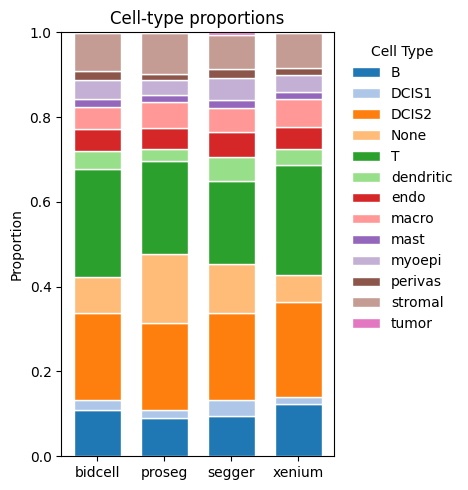

In [4]:
_ = segtraq.pl.celltype_proportions(st_dict, celltype_col="transferred_cell_type")

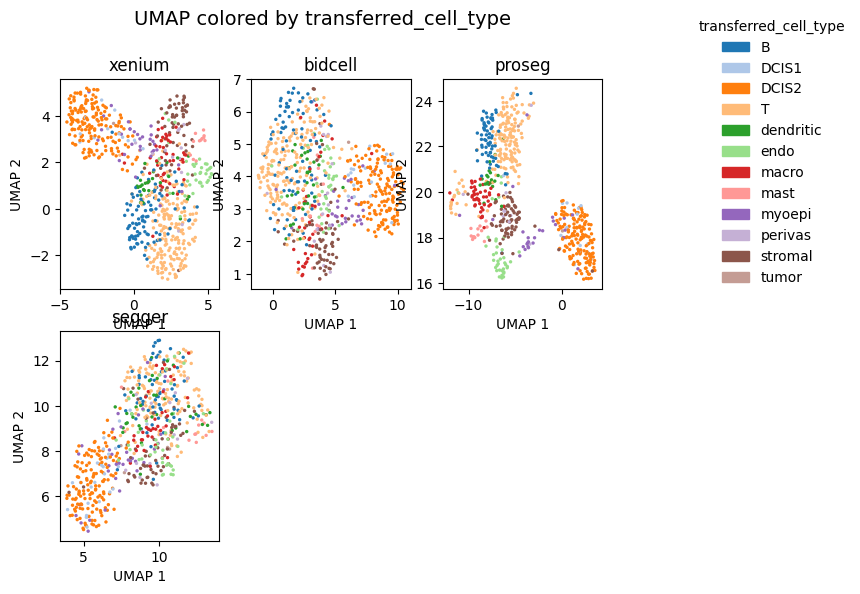

In [5]:
_ = segtraq.pl.umap(st_dict, color="transferred_cell_type", legend=True, figsize=(7, 6))

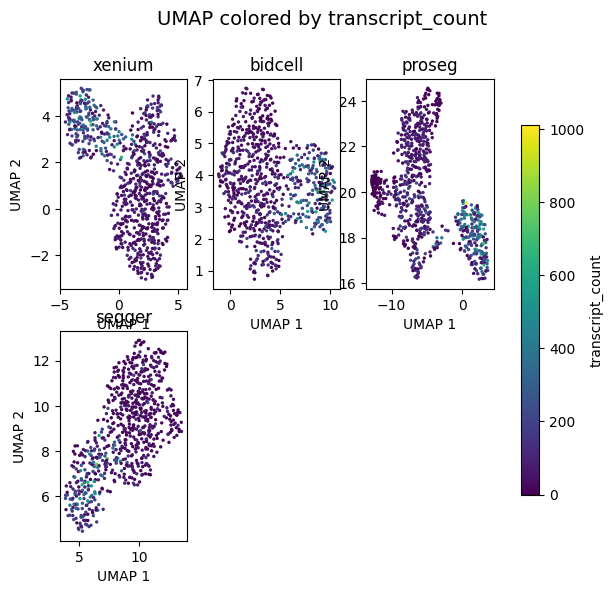

In [6]:
_ = segtraq.pl.umap(st_dict, color="transcript_count", legend=True, figsize=(7, 6))

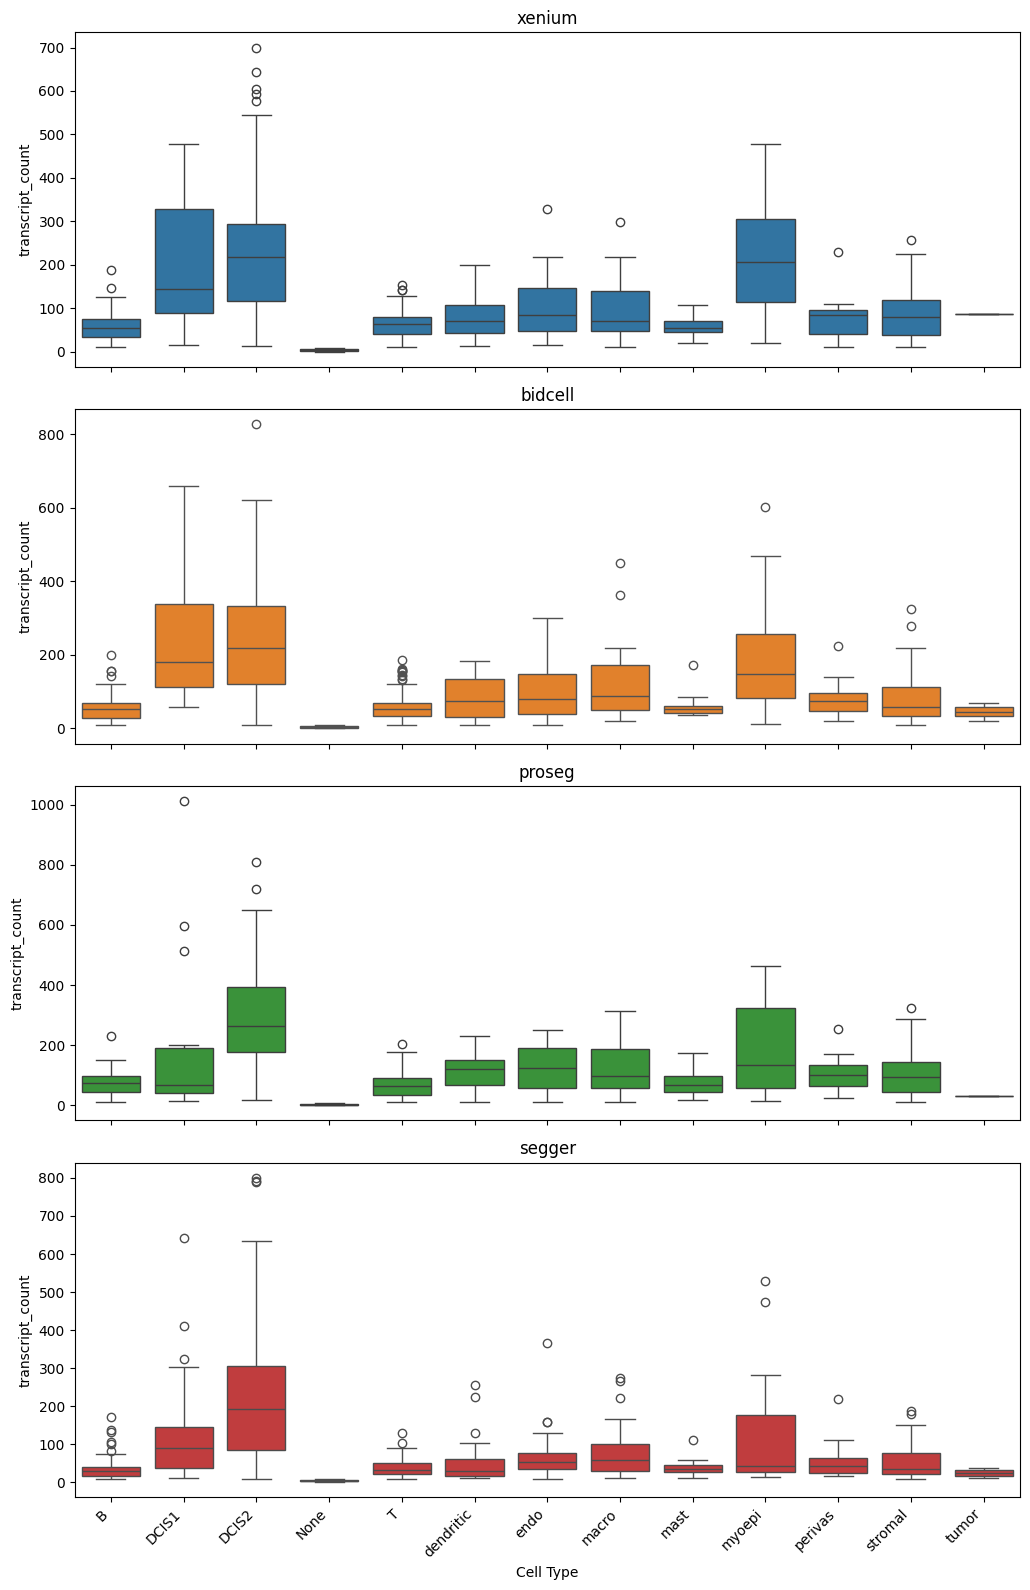

In [7]:
_ = segtraq.pl.boxplot(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")

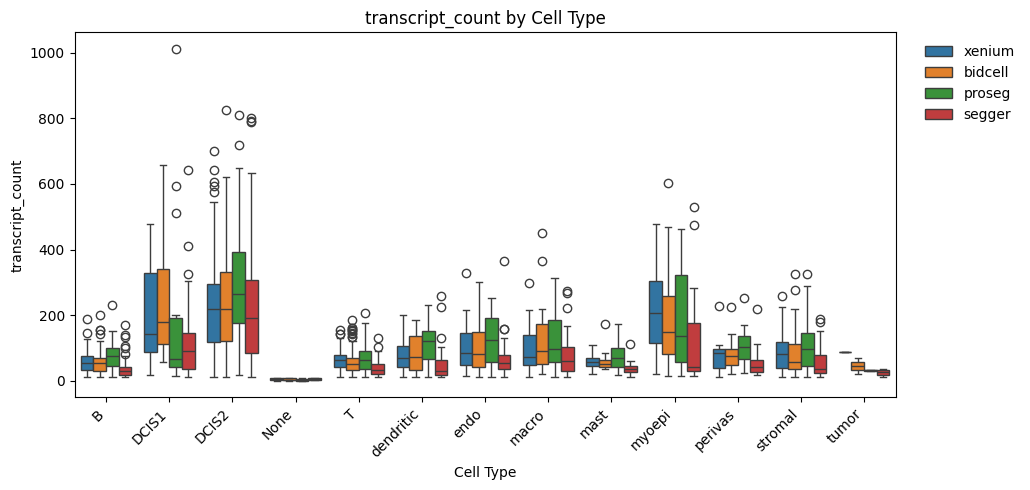

In [8]:
_ = segtraq.pl.boxplot_combined(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")